In [1]:
# Import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
from google.colab import files
uploaded = files.upload()  # Upload StudentPerformanceFactors.csv when prompted

df = pd.read_csv('StudentPerformanceFactors.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv
Dataset Shape: (6607, 20)

First 5 rows:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 n

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


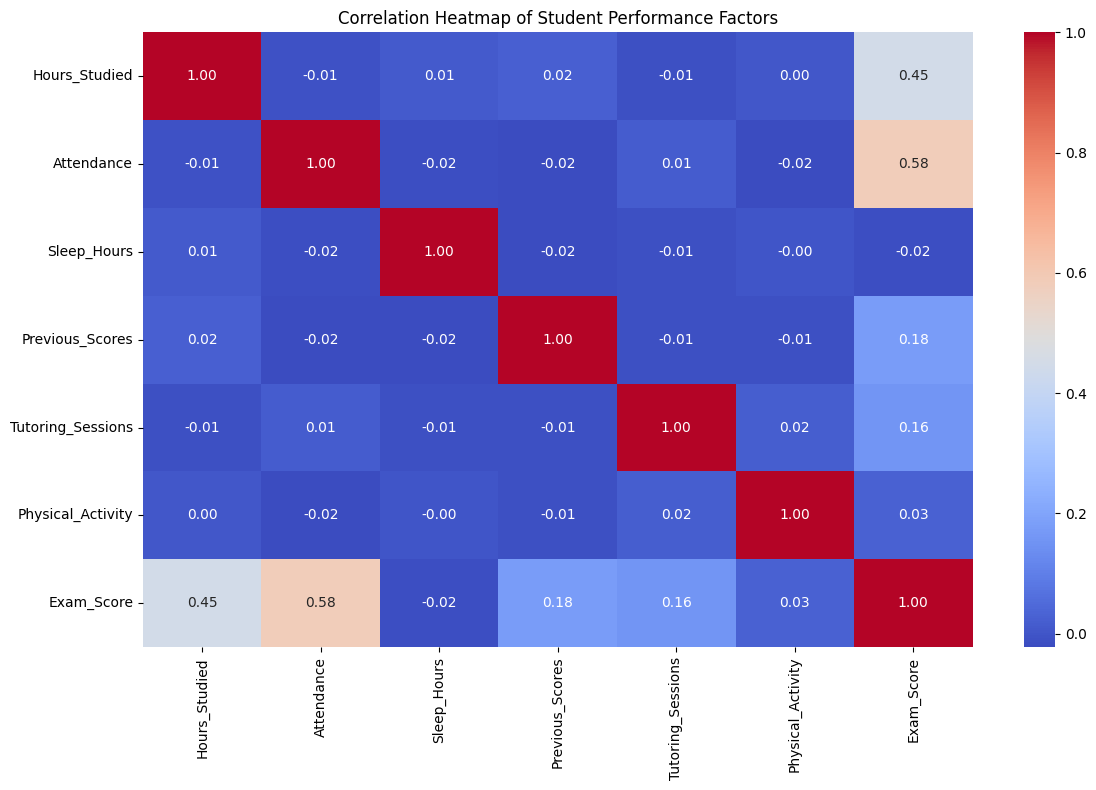

Insight: Hours Studied, Attendance and Previous Scores
show the strongest correlation with Exam Score.


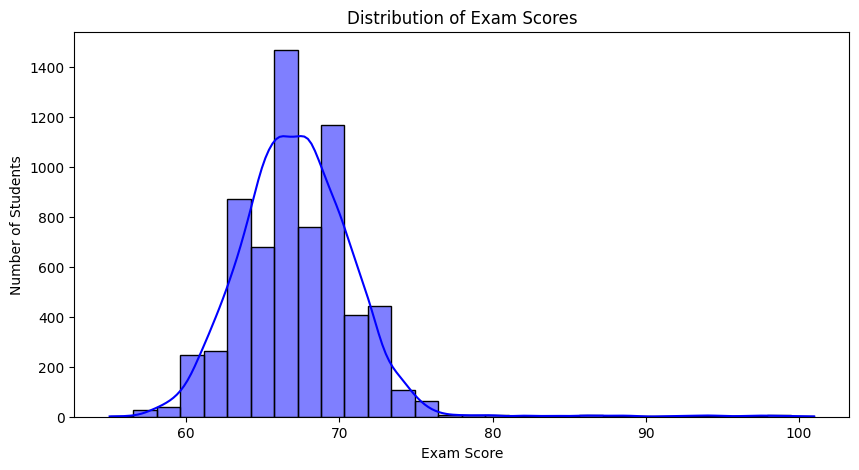

Insight: Most students score between 60-75,
showing room for improvement in underserved communities.


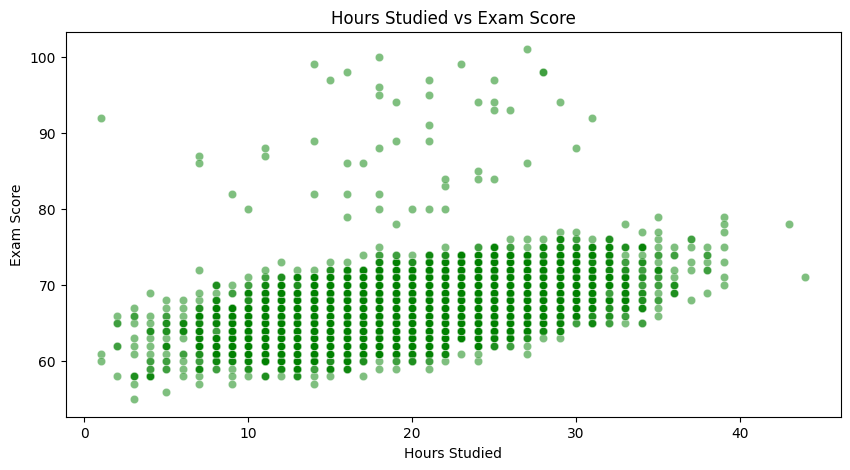

Insight: More study hours generally leads to higher exam scores.


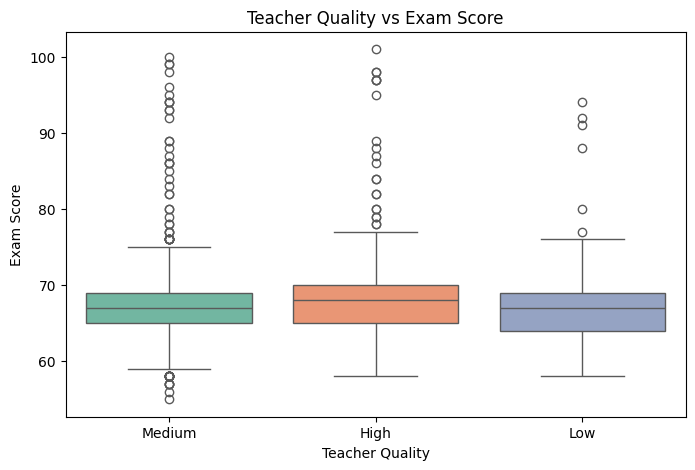

Insight: Higher teacher quality clearly leads to better exam scores,
supporting our mission of providing qualified teachers.


In [4]:
# Visualization 1: Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Student Performance Factors')
plt.tight_layout()
plt.show()
print("Insight: Hours Studied, Attendance and Previous Scores")
print("show the strongest correlation with Exam Score.")

# Visualization 2: Exam Score Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Exam_Score'], bins=30, kde=True, color='blue')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')
plt.show()
print("Insight: Most students score between 60-75,")
print("showing room for improvement in underserved communities.")

# Visualization 3: Exam Score vs Hours Studied
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, alpha=0.5, color='green')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()
print("Insight: More study hours generally leads to higher exam scores.")

# Visualization 4: Teacher Quality vs Exam Score
plt.figure(figsize=(8, 5))
sns.boxplot(x='Teacher_Quality', y='Exam_Score', data=df, palette='Set2')
plt.title('Teacher Quality vs Exam Score')
plt.xlabel('Teacher Quality')
plt.ylabel('Exam Score')
plt.show()
print("Insight: Higher teacher quality clearly leads to better exam scores,")
print("supporting our mission of providing qualified teachers.")

In [5]:
# Make a copy to work with
df_clean = df.copy()

# These columns don't help prediction - drop them
# Gender doesn't affect academic performance significantly
df_clean = df_clean.drop(columns=['Gender'])

print("Columns we are working with:")
print(df_clean.columns.tolist())

# Convert text columns to numbers using LabelEncoder
# Example: Low=0, Medium=1, High=2
le = LabelEncoder()

text_columns = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Extracurricular_Activities',
    'Motivation_Level',
    'Internet_Access',
    'Family_Income',
    'Teacher_Quality',
    'School_Type',
    'Peer_Influence',
    'Learning_Disabilities',
    'Parental_Education_Level',
    'Distance_from_Home'
]

for col in text_columns:
    df_clean[col] = le.fit_transform(df_clean[col])

print("\nAfter converting text to numbers:")
df_clean.head()

Columns we are working with:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Exam_Score']

After converting text to numbers:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,70


In [6]:
# X = everything we use to predict (features)
# y = what we are predicting (Exam Score)
X = df_clean.drop(columns=['Exam_Score'])
y = df_clean['Exam_Score']

# Split into training and testing data
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize - makes all numbers on same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("Standardization done!")

Training data size: (5285, 18)
Testing data size: (1322, 18)
Standardization done!


In [7]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Results
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("LINEAR REGRESSION RESULTS:")
print(f"Mean Squared Error (MSE): {lr_mse:.2f}")
print(f"R2 Score: {lr_r2:.2f}")
print("R2 Score means: how well the model predicts (1.0 = perfect)")

LINEAR REGRESSION RESULTS:
Mean Squared Error (MSE): 4.40
R2 Score: 0.69
R2 Score means: how well the model predicts (1.0 = perfect)


In [8]:
# Train Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predictions
dt_pred = dt_model.predict(X_test_scaled)

# Results
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("DECISION TREE RESULTS:")
print(f"Mean Squared Error (MSE): {dt_mse:.2f}")
print(f"R2 Score: {dt_r2:.2f}")

DECISION TREE RESULTS:
Mean Squared Error (MSE): 12.28
R2 Score: 0.13


In [9]:
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
rf_pred = rf_model.predict(X_test_scaled)

# Results
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("RANDOM FOREST RESULTS:")
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"R2 Score: {rf_r2:.2f}")

RANDOM FOREST RESULTS:
Mean Squared Error (MSE): 4.85
R2 Score: 0.66


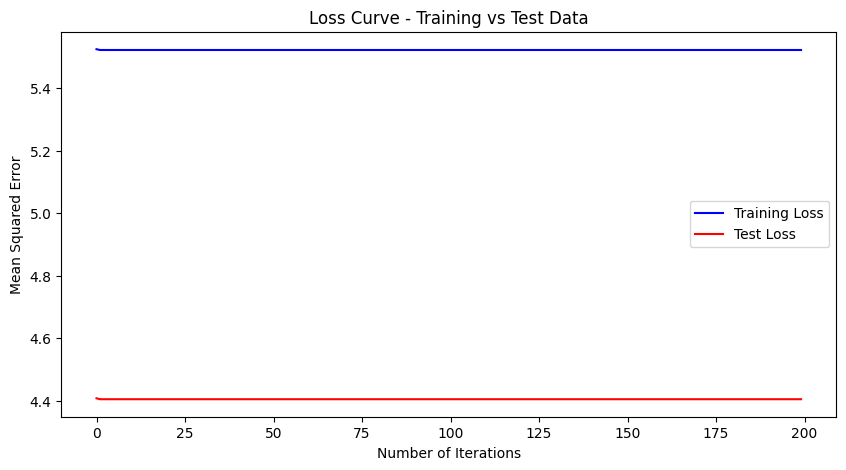

The loss going down means the model is learning and improving!


In [10]:
# Using SGDRegressor to show loss curve
train_losses = []
test_losses = []

sgd_model = SGDRegressor(max_iter=1, warm_start=True, random_state=42)

for i in range(200):
    sgd_model.fit(X_train_scaled, y_train)
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred = sgd_model.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

# Plot Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='red')
plt.title('Loss Curve - Training vs Test Data')
plt.xlabel('Number of Iterations')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()
print("The loss going down means the model is learning and improving!")

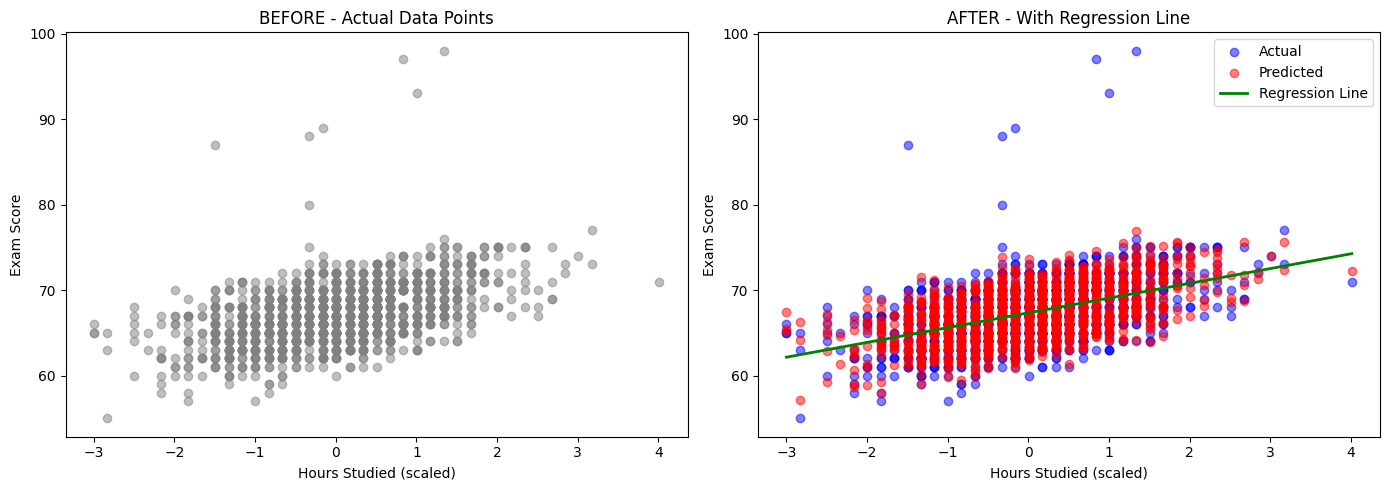

In [11]:
# BEFORE - Raw data scatter
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_test_scaled[:, 0], y_test, alpha=0.5, color='gray')
plt.title('BEFORE - Actual Data Points')
plt.xlabel('Hours Studied (scaled)')
plt.ylabel('Exam Score')

# AFTER - With regression line
plt.subplot(1, 2, 2)
plt.scatter(X_test_scaled[:, 0], y_test, alpha=0.5, color='blue', label='Actual')
plt.scatter(X_test_scaled[:, 0], lr_pred, alpha=0.5, color='red', label='Predicted')

# Draw the regression line
m, b = np.polyfit(X_test_scaled[:, 0], lr_pred, 1)
plt.plot(sorted(X_test_scaled[:, 0]),
         [m*x + b for x in sorted(X_test_scaled[:, 0])],
         color='green', linewidth=2, label='Regression Line')

plt.title('AFTER - With Regression Line')
plt.xlabel('Hours Studied (scaled)')
plt.ylabel('Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Compare all models and save the best one
print("MODEL COMPARISON:")
print(f"Linear Regression MSE: {lr_mse:.2f}")
print(f"Decision Tree MSE:     {dt_mse:.2f}")
print(f"Random Forest MSE:     {rf_mse:.2f}")

# Lower MSE = better model
best_mse = min(lr_mse, dt_mse, rf_mse)

if best_mse == lr_mse:
    best_model = lr_model
    print("\nBest Model: Linear Regression")
elif best_mse == dt_mse:
    best_model = dt_model
    print("\nBest Model: Decision Tree")
else:
    best_model = rf_model
    print("\nBest Model: Random Forest")

# Save the best model
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Best model saved as best_model.pkl!")

MODEL COMPARISON:
Linear Regression MSE: 4.40
Decision Tree MSE:     12.28
Random Forest MSE:     4.85

Best Model: Linear Regression
Best model saved as best_model.pkl!


In [13]:
# Load the saved model
loaded_model = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Take one real student from the test data
one_student = X_test.iloc[0:1]
one_student_scaled = loaded_scaler.transform(one_student)

# Predict their exam score
prediction = loaded_model.predict(one_student_scaled)
actual = y_test.iloc[0]

print("MAKING A PREDICTION FOR ONE STUDENT:")
print(f"Predicted Exam Score: {prediction[0]:.2f}")
print(f"Actual Exam Score:    {actual}")
print(f"Difference:           {abs(prediction[0] - actual):.2f} points")

MAKING A PREDICTION FOR ONE STUDENT:
Predicted Exam Score: 65.21
Actual Exam Score:    65
Difference:           0.21 points


In [14]:
from google.colab import files
files.download('best_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>